Количество фото по породам:
breed_name
Maltese_dog             252
Afghan_hound            239
Scottish_deerhound      232
Pomeranian              219
Bernese_mountain_dog    218
Samoyed                 218
Irish_wolfhound         218
Shih                    214
Great_Pyrenees          213
Leonberg                210
Name: count, dtype: int64


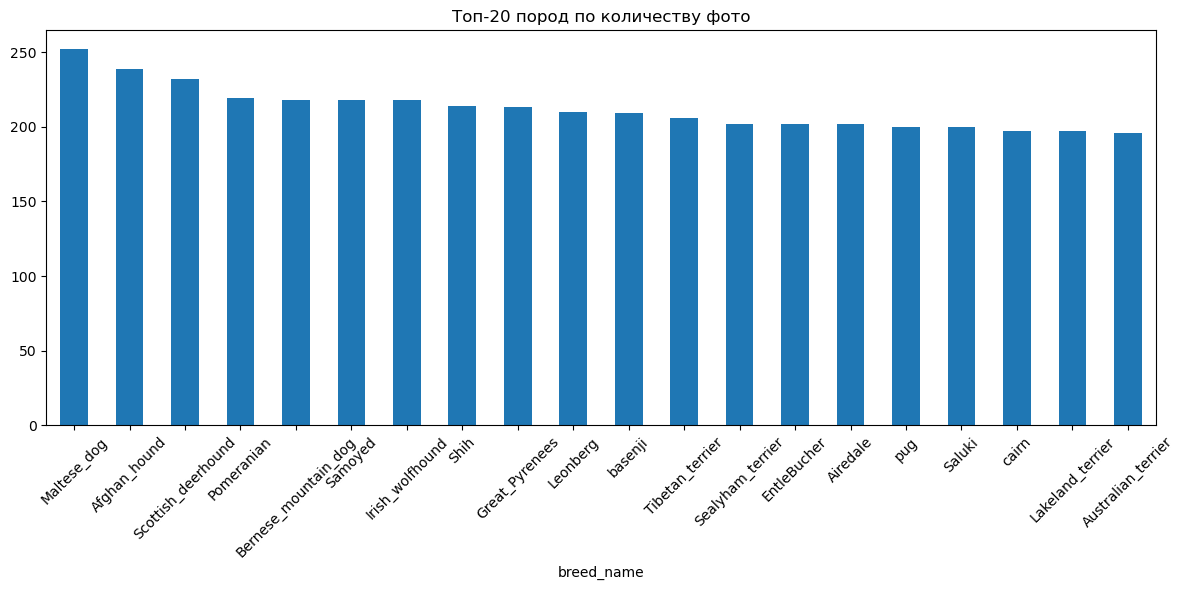

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dogs_dataset.csv')

# Статистика по породам
breed_stats = df['breed_name'].value_counts()
print("Количество фото по породам:")
print(breed_stats.head(10))

# Визуализация
plt.figure(figsize=(12, 6))
breed_stats.head(20).plot(kind='bar')
plt.title('Топ-20 пород по количеству фото')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
print(df.head(3))

    breed_id breed_name                                         image_path  \
0  n02085620  Chihuahua  images/Images/n02085620-Chihuahua/n02085620_10...   
1  n02085620  Chihuahua  images/Images/n02085620-Chihuahua/n02085620_10...   
2  n02085620  Chihuahua  images/Images/n02085620-Chihuahua/n02085620_10...   

            image_file  name_length  word_count  
0  n02085620_10074.jpg            9           1  
1  n02085620_10131.jpg            9           1  
2  n02085620_10621.jpg            9           1  


In [7]:
from PIL import Image
import random

# Случайное изображение
random_row = df.sample(1)
img_path = random_row['image_path'].values[0]
breed = random_row['breed_name'].values[0]

print(f"Порода: {breed}")
img = Image.open(img_path)
img.show()

Порода: Irish_wolfhound


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dogs_dataset.csv')

print("БАЗОВАЯ СТАТИСТИКА:")
print(f"Всего изображений: {len(df):,}")
print(f"Количество пород: {df['breed_name'].nunique()}")
print(f"Среднее фото на породу: {len(df) // df['breed_name'].nunique()}")

# Статистика по породам
breed_stats = df['breed_name'].value_counts()
print("\n ТОП-10 пород по количеству фото:")
for i, (breed, count) in enumerate(breed_stats.head(10).items(), 1):
    print(f"{i:2d}. {breed:<25} - {count:>3} фото")

print("\n НИЗ-10 пород по количеству фото:")
for i, (breed, count) in enumerate(breed_stats.tail(10).items(), 1):
    print(f"{i:2d}. {breed:<25} - {count:>3} фото")

БАЗОВАЯ СТАТИСТИКА:
Всего изображений: 20,580
Количество пород: 120
Среднее фото на породу: 171

 ТОП-10 пород по количеству фото:
 1. Maltese_dog               - 252 фото
 2. Afghan_hound              - 239 фото
 3. Scottish_deerhound        - 232 фото
 4. Pomeranian                - 219 фото
 5. Bernese_mountain_dog      - 218 фото
 6. Samoyed                   - 218 фото
 7. Irish_wolfhound           - 218 фото
 8. Shih                      - 214 фото
 9. Great_Pyrenees            - 213 фото
10. Leonberg                  - 210 фото

 НИЗ-10 пород по количеству фото:
 1. malinois                  - 150 фото
 2. groenendael               - 150 фото
 3. Eskimo_dog                - 150 фото
 4. kuvasz                    - 150 фото
 5. golden_retriever          - 150 фото
 6. Irish_water_spaniel       - 150 фото
 7. affenpinscher             - 150 фото
 8. Bouvier_des_Flandres      - 150 фото
 9. Pekinese                  - 149 фото
10. redbone                   - 148 фото


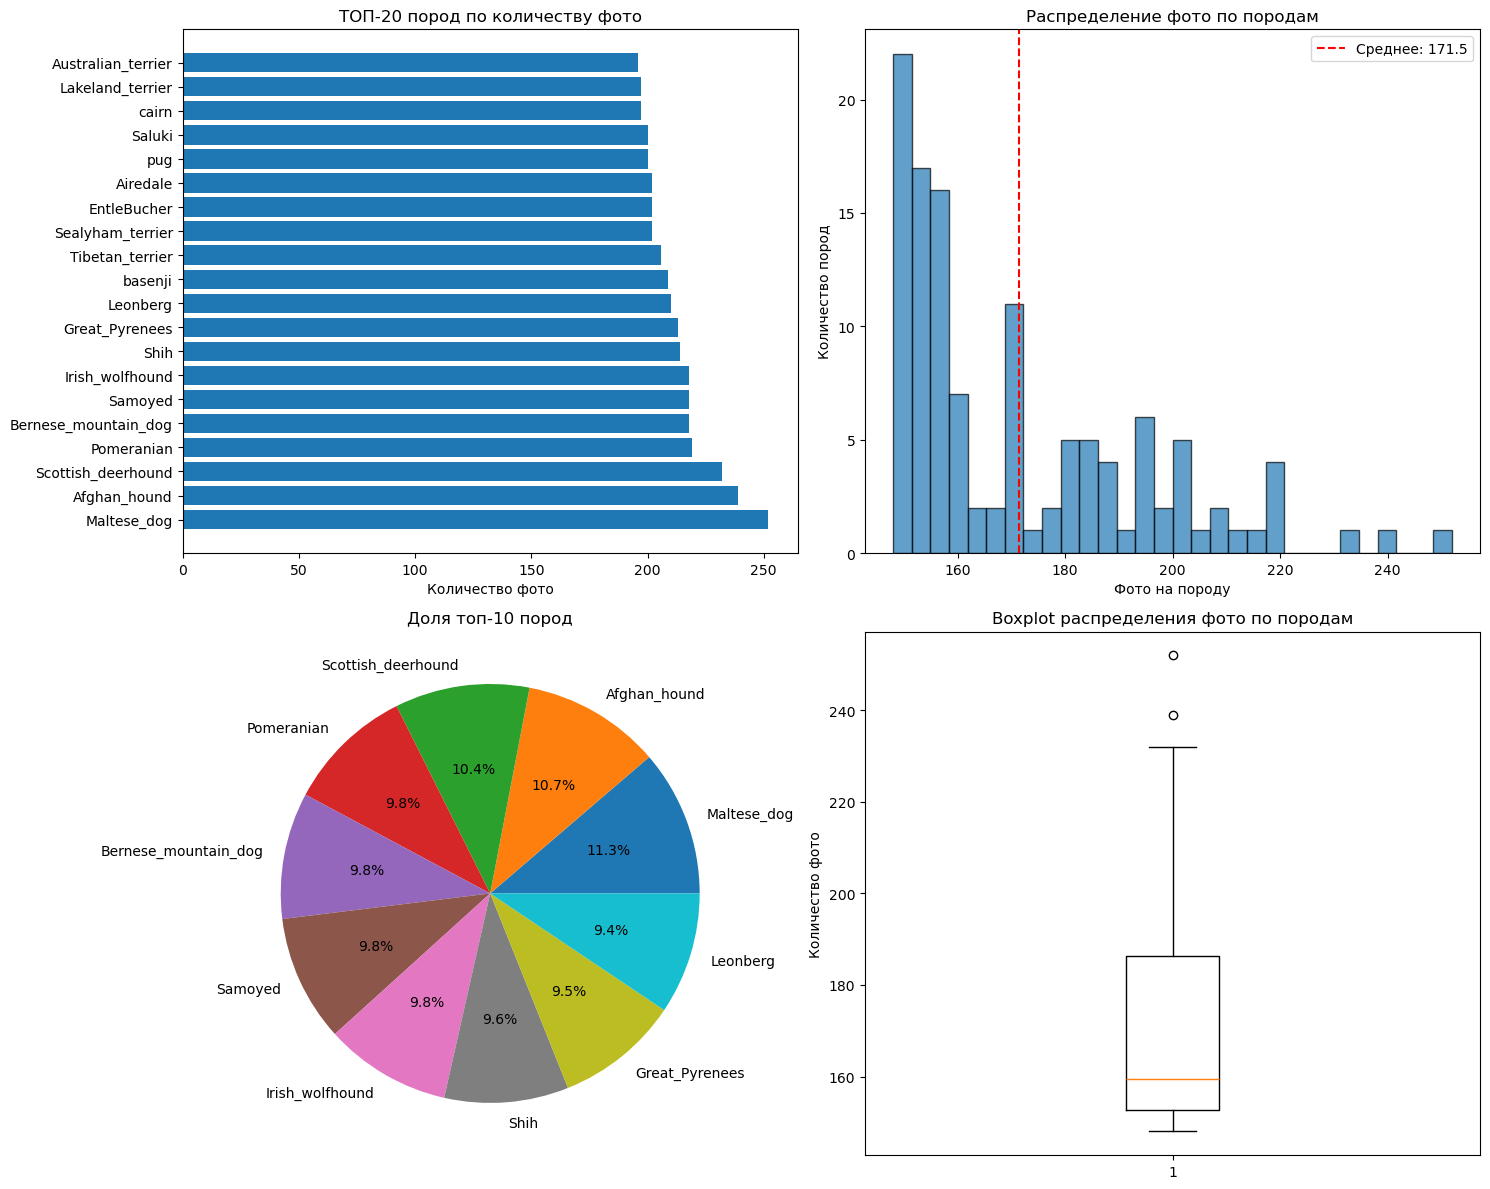

In [11]:
# Настройка стиля
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Топ-20 пород
top_20 = breed_stats.head(20)
axes[0,0].barh(range(len(top_20)), top_20.values)
axes[0,0].set_yticks(range(len(top_20)))
axes[0,0].set_yticklabels(top_20.index)
axes[0,0].set_title('ТОП-20 пород по количеству фото')
axes[0,0].set_xlabel('Количество фото')

# 2. Распределение количества фото
axes[0,1].hist(breed_stats.values, bins=30, edgecolor='black', alpha=0.7)
axes[0,1].axvline(breed_stats.mean(), color='red', linestyle='--', label=f'Среднее: {breed_stats.mean():.1f}')
axes[0,1].set_title('Распределение фото по породам')
axes[0,1].set_xlabel('Фото на породу')
axes[0,1].set_ylabel('Количество пород')
axes[0,1].legend()

# 3. Круговая диаграмма (топ-10)
top_10 = breed_stats.head(10)
axes[1,0].pie(top_10.values, labels=top_10.index, autopct='%1.1f%%')
axes[1,0].set_title('Доля топ-10 пород')

# 4. Boxplot распределения
axes[1,1].boxplot(breed_stats.values)
axes[1,1].set_title('Boxplot распределения фото по породам')
axes[1,1].set_ylabel('Количество фото')

plt.tight_layout()
plt.show()

In [12]:
# Дополнительный анализ
print("\n АНАЛИЗ НАЗВАНИЙ ПОРОД:")

# Длина названий пород
df['name_length'] = df['breed_name'].str.len()
print(f"Средняя длина названия породы: {df['name_length'].mean():.1f} символов")

# Породы с самыми длинными названиями
long_names = df[['breed_name', 'name_length']].drop_duplicates().nlargest(5, 'name_length')
print("\nПороды с самыми длинными названиями:")
for _, row in long_names.iterrows():
    print(f"  {row['breed_name']} - {int(row['name_length'])} симв.")

# Количество слов в названии
df['word_count'] = df['breed_name'].str.split().str.len()
multi_word = df[df['word_count'] > 1]['breed_name'].unique()
print(f"\nПороды с составными названиями ({len(multi_word)}):")
print(", ".join(multi_word))


 АНАЛИЗ НАЗВАНИЙ ПОРОД:
Средняя длина названия породы: 12.3 символов

Породы с самыми длинными названиями:
  American_Staffordshire_terrier - 30 симв.
  West_Highland_white_terrier - 27 симв.
  Greater_Swiss_Mountain_dog - 26 симв.
  Staffordshire_bullterrier - 25 симв.
  Chesapeake_Bay_retriever - 24 симв.

Породы с составными названиями (0):



In [14]:
# Создаем сводную таблицу
summary = pd.DataFrame({
    'total_images': len(df),
    'total_breeds': df['breed_name'].nunique(),
    'avg_images_per_breed': round(len(df) / df['breed_name'].nunique()),
    'max_images': breed_stats.max(),
    'min_images': breed_stats.min(),
    'median_images': breed_stats.median()
}, index=['статистика'])

print("\n СВОДНАЯ СТАТИСТИКА ДАТАСЕТА:")
print(summary.T)


 СВОДНАЯ СТАТИСТИКА ДАТАСЕТА:
                      статистика
total_images             20580.0
total_breeds               120.0
avg_images_per_breed       172.0
max_images                 252.0
min_images                 148.0
median_images              159.5
